<a href="https://colab.research.google.com/github/sruthi-analyst/sruthi-codeboosters-2026/blob/main/Day2/Day_2_task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt #data visualisation library
import warnings                 #errors might come for versions and other things, so we import warnings and then tell the system to ignore them all for smooth functioning of the program
warnings.filterwarnings('ignore')

print("All libraries imported succefully")
print("Pandas version: ", pd.__version__)
print("sqlite3 version: ", sqlite3.version)

All libraries imported succefully
Pandas version:  2.2.2
sqlite3 version:  2.6.0


In [43]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/datasets/student_performance.csv")

In [55]:
conn = sqlite3.connect('College.db') #connection object connecting Python environment to SQLite database file College.db
cursor = conn.cursor()
df.to_sql(
    'students',     #Name of table to creare in the database
    conn,           #Which db connection object to use
    if_exists = 'replace', #Is 'students' tab;e exists, replace it
    index=False     #Do not write DataFrame row numbes as a column
)

30

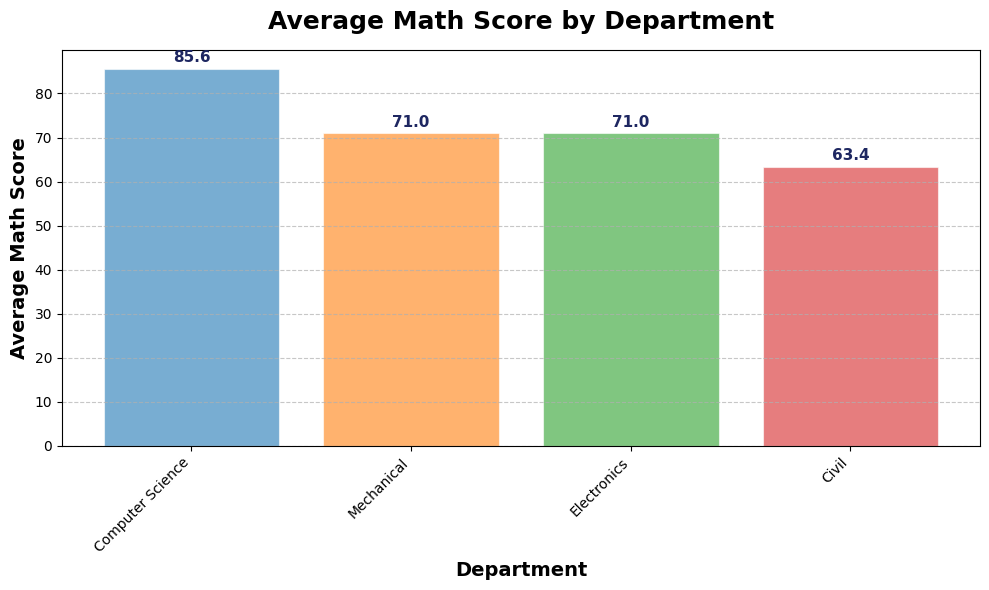

In [77]:
chart1_sql = """
SELECT department,
ROUND(AVG(math_score), 2) AS avg_math
FROM students
GROUP BY department
ORDER BY avg_math DESC
"""
chart1_data = pd.read_sql_query(chart1_sql, conn)

#2: Create the bar chart
fig, ax = plt.subplots(figsize=(10, 6))

bar_colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink', 'tab:gray', 'tab:olive', 'tab:cyan']
bars = ax.bar(chart1_data['department'], chart1_data['avg_math'], color=bar_colors, edgecolor='white', linewidth=0.8, alpha=0.6)

for bar in bars:
  height=bar.get_height()
  ax.text(
      bar.get_x()+bar.get_width()/2,
      height+0.8,
      f'{height:.1f}',
      ha='center', va='bottom',
      fontsize=11, fontweight='bold',
      color='#1E2761'
  )

ax.set_title("Average Math Score by Department", fontsize=18, fontweight='bold', pad=15)
ax.set_xlabel("Department", fontsize=14, fontweight='bold')
ax.set_ylabel("Average Math Score", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels
ax.yaxis.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

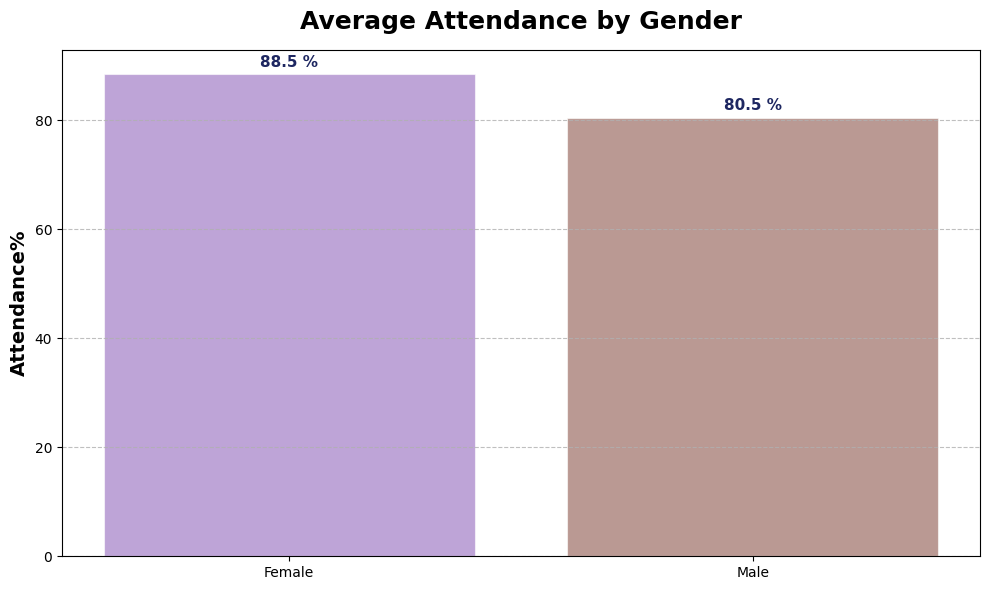

In [51]:
chart1_sql = """
      SELECT gender,
      ROUND(AVG(attendance_percentage), 1) AS avg_attendance
      FROM students
      GROUP BY gender
      ORDER BY avg_attendance DESC
"""
chart1_data = pd.read_sql_query(chart1_sql, conn)

#2: Create the bar chart
fig, ax = plt.subplots(figsize=(10, 6))

bar_colors = ['tab:purple', 'tab:brown', 'tab:pink', 'tab:gray', 'tab:olive', 'tab:cyan', 'tab:blue', 'tab:orange', 'tab:green', 'tab:red']
bars = ax.bar(chart1_data['gender'], chart1_data['avg_attendance'], color=bar_colors, edgecolor='white', linewidth=0.8, alpha=0.6)

for bar in bars:
  height=bar.get_height()
  ax.text(
      bar.get_x()+bar.get_width()/2,
      height+0.8,
      f'{height:.1f} %',
      ha='center', va='bottom',
      fontsize=11, fontweight='bold',
      color='#1E2761'
  )

ax.set_title("Average Attendance by Gender", fontsize=18, fontweight='bold', pad=15)
ax.set_ylabel("Attendance%", fontsize=14, fontweight='bold')
ax.yaxis.grid(True, linestyle='--', alpha=0.8)

plt.tight_layout()
plt.show()

In [79]:
df['total_score'] = df['math_score'] + df['science_score'] + df['programming_score'] + df['english_score']
df.columns
df.to_sql(
    'students',     #Name of table to creare in the database
    conn,           #Which db connection object to use
    if_exists = 'replace', #Is 'students' tab;e exists, replace it
    index=False     #Do not write DataFrame row numbes as a column
)
print("Total_score column added successfully")

Total_score column added successfully


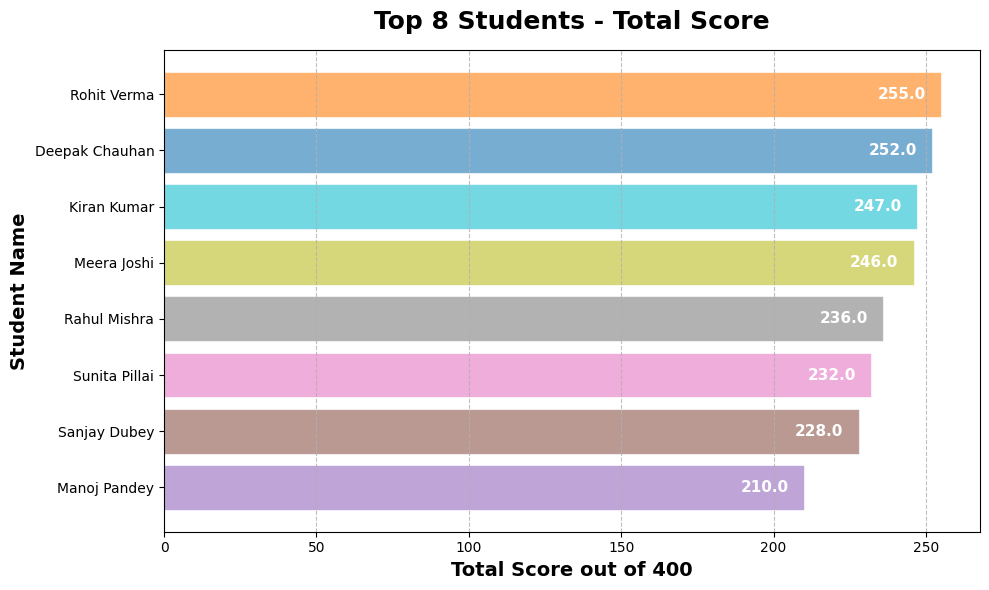

In [80]:
chart2_sql = """
      SELECT total_score, name
      FROM students
      ORDER BY total_score LIMIT 8
"""
chart2_data = pd.read_sql_query(chart2_sql, conn)

#2: Create the horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 6))

bar_colors = ['tab:purple', 'tab:brown', 'tab:pink', 'tab:gray', 'tab:olive', 'tab:cyan', 'tab:blue', 'tab:orange', 'tab:green', 'tab:red']
bars = ax.barh(chart2_data['name'], chart2_data['total_score'], color=bar_colors, edgecolor='white', linewidth=0.8, alpha=0.6)

for bar in bars:
  width = bar.get_width()
  ax.text(
      width - 5,  # Adjust text position to be inside the bar
      bar.get_y() + bar.get_height()/2,
      f'{width:.1f}',
      ha='right', va='center', # Align text to the right
      fontsize=11, fontweight='bold',
      color='white' # Set text color to white for better visibility inside bars
  )

ax.set_title("Top 8 Students - Total Score", fontsize=18, fontweight='bold', pad=15)
ax.set_xlabel("Total Score out of 400", fontsize=14, fontweight='bold')
ax.set_ylabel("Student Name", fontsize=14, fontweight='bold') # Update y-axis label for horizontal chart
ax.xaxis.grid(True, linestyle='--', alpha=0.8) # Add grid for x-axis for horizontal bars

plt.tight_layout()
plt.show()

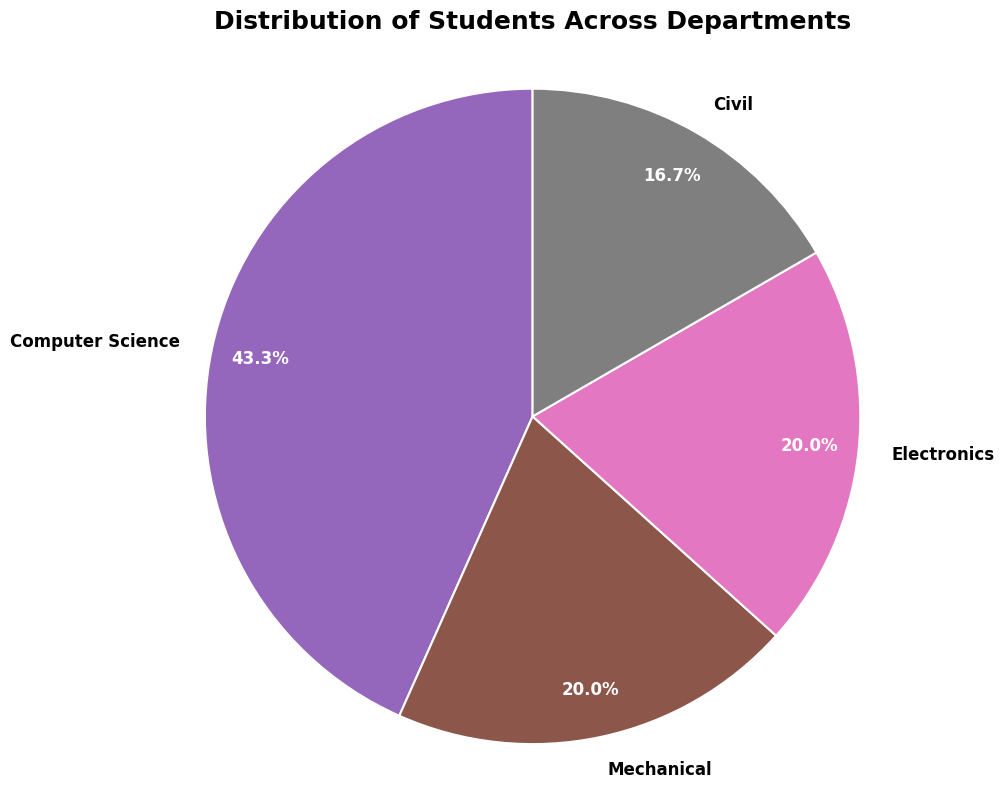

In [81]:
chart3_sql = """
      SELECT department, COUNT(student_id) AS student_count
      FROM students
      GROUP BY department
      ORDER BY student_count DESC
"""
chart3_data = pd.read_sql_query(chart3_sql, conn)

# 3: Create the pie chart
fig, ax = plt.subplots(figsize=(10, 8))

pie_colors = bar_colors[:len(chart3_data['department'])]

wedges, texts, autotexts = ax.pie(
    chart3_data['student_count'],
    labels=chart3_data['department'],
    autopct='%1.1f%%', # Format percentage displayed on wedges
    startangle=90,     # Start the first slice at the top
    colors=pie_colors, # Use the defined colors
    pctdistance=0.85,  # Distance of percentage labels from the center
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5} # Add white borders to wedges
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')

# Customize label text
for text in texts:
    text.set_fontsize(12)
    text.set_fontweight('bold')

ax.set_title("Distribution of Students Across Departments", fontsize=18, fontweight='bold', pad=20)
ax.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.

plt.tight_layout()
plt.show()

In [82]:
sql_query1 = "SELECT ROUND(AVG(programming_score), 2) AS avg_programming_score FROM students WHERE gender='Female'"
print(f"{'='*30}")
print(pd.read_sql_query(sql_query1, conn).to_string(index=False))
print(f"{'='*30}")
sql_query2 = "SELECT department AS Department, ROUND(AVG(attendance_percentage), 2) AS Avg_Attendance FROM students GROUP BY department HAVING Avg_Attendance >85"
print(pd.read_sql_query(sql_query2, conn).to_string(index=False))
print(f"{'='*30}")

 avg_programming_score
                  70.2
      Department  Avg_Attendance
Computer Science           90.69


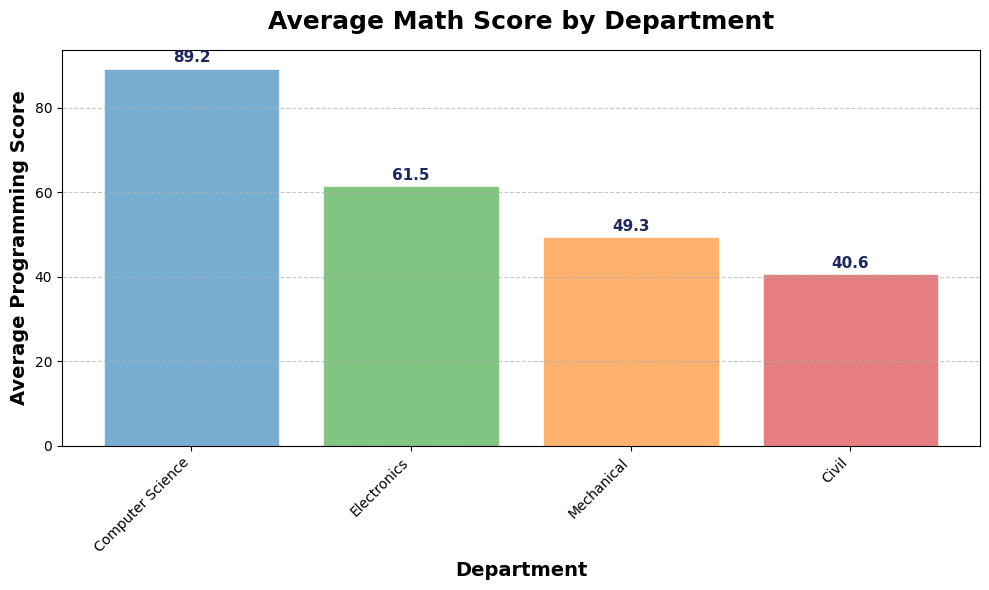

In [84]:
chart1_sql = """
SELECT department,
ROUND(AVG(programming_score), 2) AS avg_programming
FROM students
GROUP BY department
ORDER BY avg_programming DESC
"""
chart1_data = pd.read_sql_query(chart1_sql, conn)

#2: Create the bar chart
fig, ax = plt.subplots(figsize=(10, 6))

bar_colors = ['tab:blue', 'tab:green', 'tab:orange', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink', 'tab:gray', 'tab:olive', 'tab:cyan']
bars = ax.bar(chart1_data['department'], chart1_data['avg_programming'], color=bar_colors, edgecolor='white', linewidth=0.8, alpha=0.6)

for bar in bars:
  height=bar.get_height()
  ax.text(
      bar.get_x()+bar.get_width()/2,
      height+0.8,
      f'{height:.1f}',
      ha='center', va='bottom',
      fontsize=11, fontweight='bold',
      color='#1E2761'
  )

ax.set_title("Average Math Score by Department", fontsize=18, fontweight='bold', pad=15)
ax.set_xlabel("Department", fontsize=14, fontweight='bold')
ax.set_ylabel("Average Programming Score", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels
ax.yaxis.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()